## 1 - Exploración inicial
Antes de aplicar un algoritmo de clustering, analice la estructura del conjunto de datos customer_data.csv y analice las variables Age e Income mediante estadísticos descriptivos. Represente gráficamente la relación entre edad e ingreso.

¿Se observan grupos claramente separados a simple vista en el plano edad-ingreso?

               Age         Income
count  2000.000000    2000.000000
mean     35.909000  120954.419000
std      11.719402   38108.824679
min      18.000000   35832.000000
25%      27.000000   97663.250000
50%      33.000000  115548.500000
75%      42.000000  138072.250000
max      76.000000  309364.000000


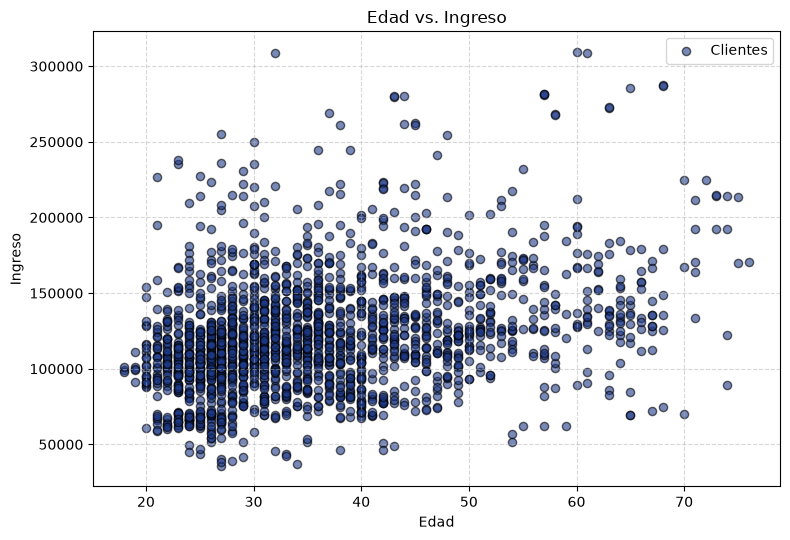

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

clientes_df = pd.read_csv("./data/customer_data.csv")

print(clientes_df[['Age', 'Income']].describe())

plt.figure(figsize = (8, 5.5))

plt.scatter(
    clientes_df['Age'],
    clientes_df['Income'],
    color = '#1E3A8A',
    alpha=0.6,
    edgecolor='k',
    s=35, 
    label = 'Clientes'
)


plt.title('Edad vs. Ingreso')
plt.xlabel('Edad')
plt.ylabel('Ingreso')
plt.grid(True, linestyle = '--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

No pueden observarse grupos claramente delimitados. Si bien no todos los datos están agrupados en un solo espacio, no existen vacíos significativos que delimiten dos grupos. Sin embargo hay una gran concentración notable en la esquina inferior izquierda y una mayor dispersión en la parte superior derecha.

### 2. Selección de características y escalado

Para construir los clusters se utilizarán únicamente:

$$
X = [\text{Age},\text{Income}]
$$

Las demás variables se reservarán para describir los segmentos una vez obtenidos.

### 3. Selección del número de clusters con K-Means

No se conoce de antemano cuántos grupos existen en los datos.

1. Ajuste K-Means para valores de $K$ entre 1 y 10.
2. Registre la inercia o WCSS para cada valor de $K$.
3. Para $K \geq 2$, calcule además el coeficiente de silueta promedio.
4. Represente:
   - WCSS en función de $K$.
   - coeficiente de silueta promedio en función de $K$.
5. Identifique los valores de $K$ que considera más razonables y justifique.

RESULTADOS
 K   Inercia Silueta Promedio
 1 4000.0000              NaN
 2 2260.2037           0.4424
 3 1647.5540           0.4394
 4 1281.1447           0.3503
 5 1024.2394           0.3648
 6  865.9056           0.3555
 7  751.3056           0.3556
 8  665.0295           0.3561
 9  582.9290           0.3617
10  511.2343           0.3674


AttributeError: 'numpy.ndarray' object has no attribute 'plot'

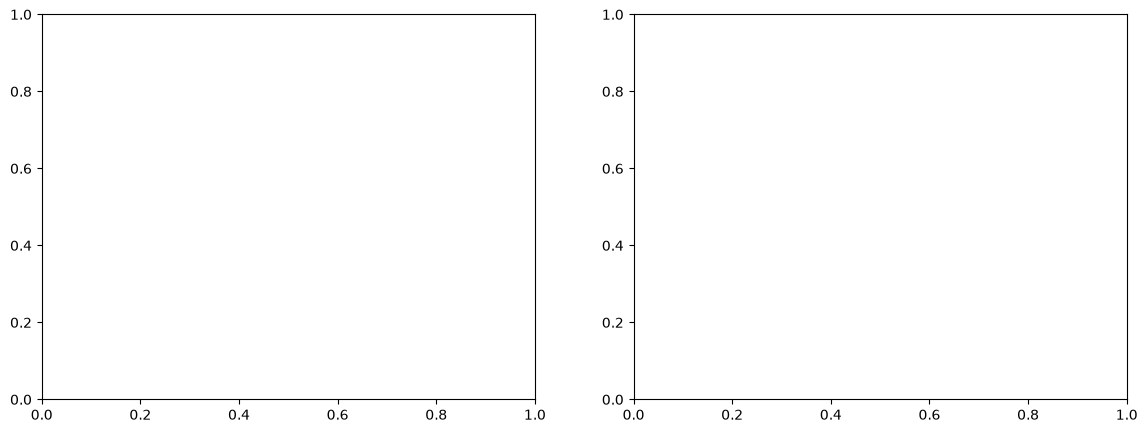

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

clientes_df = pd.read_csv('./data/customer_data.csv')

columnas = clientes_df[['Age', 'Income']]

#Escalamos
scaler = StandardScaler()
columnas_escaladas = scaler.fit_transform(columnas)

k_rango = range(1,11)
inercias = []
coeficientes_silueta = []

for k in k_rango:
    kmeans =  KMeans(n_clusters = k, random_state = 42, n_init = 10)
    kmeans.fit(columnas_escaladas)

    inercias.append(kmeans.inertia_)

    if k>=2:
        coeficiente = silhouette_score(columnas_escaladas, kmeans.labels_)
        coeficientes_silueta.append(coeficiente)
    else:
        coeficientes_silueta.append(np.nan)
df_resultados = pd.DataFrame({
    'K': k_rango,
    'Inercia': inercias,
    'Silueta Promedio': coeficientes_silueta
})

print("RESULTADOS")
print(df_resultados.to_string(index = False, formatters={
    'Inercia': '{:.4f}'.format,
    'Silueta Promedio': lambda x: '{:.4f}'.format(x) if not np.isnan(x) else 'N/A'
}))



fig, axs = plt.subplots(1, 2, figsize=(14, 5))
#Grafica de Codo
axs[0].plot(k_rango, inercias, marker='o', linestyle = '--', color='#1E3A8A', label='Inercias')
axs[0].set_title('Método del Codo', pad = 10)
axs[0].set_xlabel('K')
axs[0].set_ylabel('Inercias')
axs[0].set_xticks(k_rango)
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].legends()

#Coeficiente de Silueta vs. K
axs[1].plot(list(range(2,11)), coeficientes_silueta[1:], marker='s', linestyle='--', label='Silueta Promedio')
axs[1].set_title('Coeficiente de Silueta Promedio vs. K')
axs[1].set_xlaber('K')
axs[1].set_ylabel('Indice de Silueta')
axs[1].set_xticks(range(2,11))
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].legend()

plt.tight_layout()
plt.show()